## STROKE PREDICTION MODEL (Machine Learning)
### Context 
The World Health Organization identifies stroke as the second leading cause of death worldwide, accounting for roughly 11% of all global deaths. This dataset aims to predict a patient's likelihood of experiencing a stroke by analyzing key input parameters such as gender, age, pre-existing medical conditions, and smoking status.
The model will be a supervised classification model. Since we have access to the ground truth labels, the model is trained on known outcomes and its performance is evaluated against them. The task is to predict whether a patient had a stroke 1 or did not 0.

## 1.Import Libraries

In [5]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2.Load Data

In [7]:
df = pd.read_csv("stroke-data.csv", sep=";")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3.Exploratory Data Analysis (EDA)

In [9]:
## check numerical column first
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


##### Comments
Data are imbalanced : 4.9% had a stroke  
BMI : The BMI column contains missing values and covers extreme ranges, from 10.3 (severe underweight) to 97.6 (extreme obesity). Missing values were handled through imputation or column removal  
Age : The dataset spans a wide age range, from 0.08 years (newborn) to 82 years old  
Avg glucose level Average Glucose Level : The distribution of average glucose level is right-skewed, with potential outliers present  
Id : The ID column is not relevant as a predictive feature and should be excluded from modeling

#### 3.a Target : Stroke

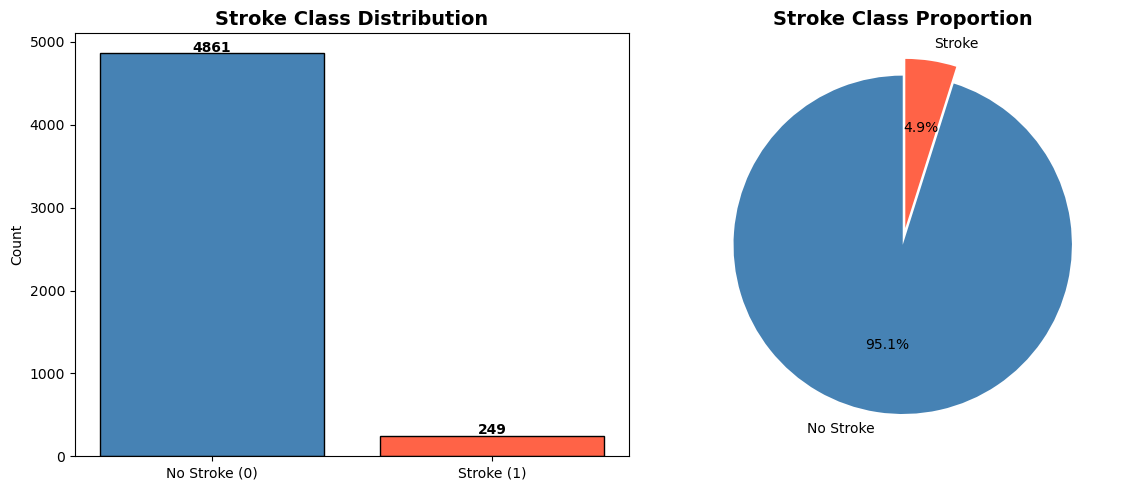

Stroke cases: 249 (4.9%)
No stroke cases: 4861 (95.1%)


In [11]:
## Plot to confirm that stroke data are imbalanced  

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke (0)', 'Stroke (1)'], counts.values,color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Stroke Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%', startangle=90, explode=(0, 0.1),colors=['steelblue', 'tomato'])
axes[1].set_title('Stroke Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Stroke cases: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"No stroke cases: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")

These count plots and pie charts confirm that the stroke data is imbalanced 

#### 3.b Feature/Index : id 

In [13]:
print(f"Unique IDs: {df['id'].nunique()} / Total rows: {len(df)}")
print(f"ID range: {df['id'].min()} to {df['id'].max()}")

Unique IDs: 5110 / Total rows: 5110
ID range: 67 to 72940


id is unique for each rows carries no information, it's an index (non relevant for ML)

#### 3.c Features Numeric columns (continuous), age, avg_glucose_level, bmi 

##### Age

In [19]:
print(df['age'].describe())
# age between 0 and 82 years old with a mean at 43 

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64


NameError: name 'stats' is not defined

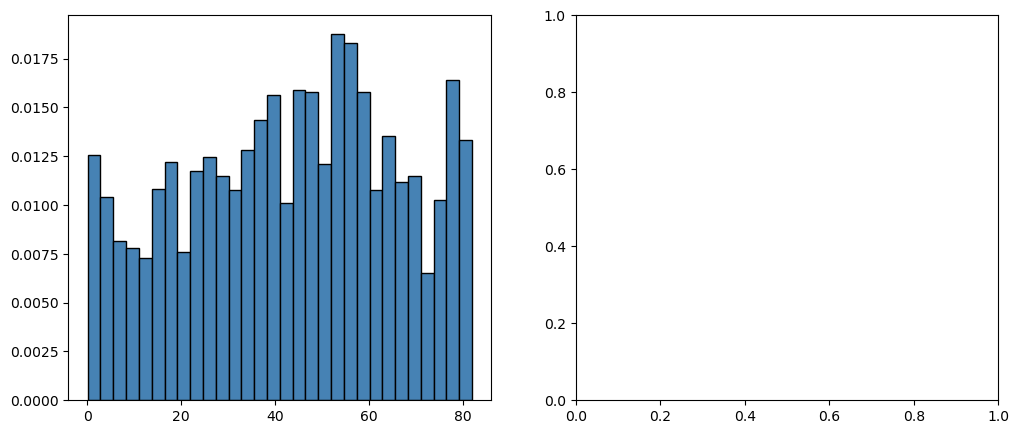

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with normal curve overlay
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', density=True)
mu, std = df['age'].mean(), df['age'].std()
x = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0].plot(x, stats.norm.pdf(x, mu, std), color='tomato', linewidth=2, label='Normal curve')
axes[0].set_title('Age Distribution vs Normal Curve', fontweight='bold')
axes[0].legend()

# Boxplot (shows outliers)
axes[1].boxplot(df['age'], patch_artist=True, boxprops=dict(facecolor='steelblue'))
axes[1].set_title('Age Boxplot', fontweight='bold')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

Age skews toward older 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram with count
ax.hist(df['age'], bins=30, color='steelblue', edgecolor='black')
ax.set_title('Age Distribution', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')

# Normal curve scaled to count
mu, std = df['age'].mean(), df['age'].std()
x = np.linspace(df['age'].min(), df['age'].max(), 100)
bin_width = (df['age'].max() - df['age'].min()) / 30
ax.plot(x, stats.norm.pdf(x, mu, std) * len(df['age']) * bin_width, 
        color='tomato', linewidth=2, label='Normal curve')
ax.legend()

plt.tight_layout()
plt.show()

Age distribution is close to normal

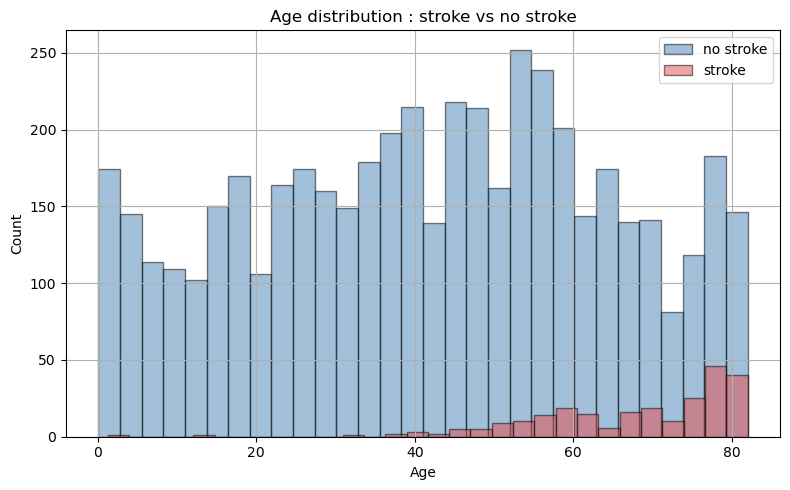

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

df.loc[df.stroke == 0, "age"].hist(bins=30, ax=ax, alpha=0.5, 
                                    color='steelblue', edgecolor='black', label="no stroke")
df.loc[df.stroke == 1, "age"].hist(bins=30, ax=ax, alpha=0.5, 
                                    color="#E24B4A",edgecolor='black', label="stroke")

ax.set_title("Age distribution : stroke vs no stroke")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

There is a strong separation between the two groups, as stroke cases are clearly concentrated in older age ranges  
Age is likely to be a relevant and significant feature for machine learning

##### BMI

In [29]:
## Print missing values 
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

201 bmi values are missing 

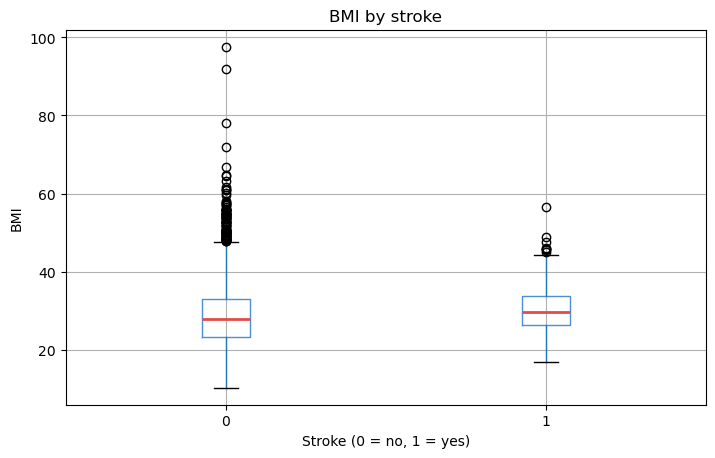

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column="bmi", by="stroke", ax=ax, 
           boxprops=dict(color="#4A90D9"),
           medianprops=dict(color="#E24B4A", linewidth=2))

ax.set_title("BMI by stroke")
ax.set_xlabel("Stroke (0 = no, 1 = yes)")
ax.set_ylabel("BMI")
plt.suptitle("")  # removes the default ugly pandas title
plt.show()

Median bmi is close between groups stroke vs no stroke, but the distribution is different   
More outliers for stroke patients   
BMI alone may not be a strong predictive feature, but may contribute in combination with others  

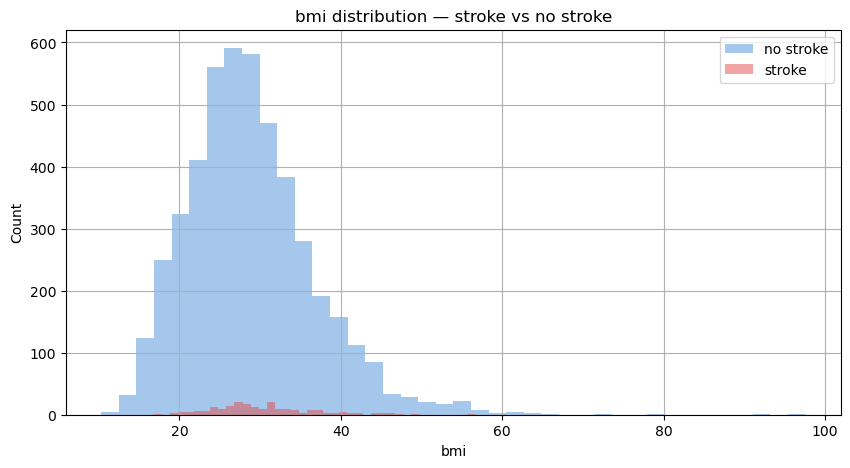

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

df.loc[df.stroke == 0, "bmi"].hist(bins=40, ax=ax, alpha=0.5, 
                                    color="#4A90D9", label="no stroke")
df.loc[df.stroke == 1, "bmi"].hist(bins=40, ax=ax, alpha=0.5, 
                                    color="#E24B4A", label="stroke")

ax.set_title("bmi distribution — stroke vs no stroke")
ax.set_xlabel("bmi")
ax.set_ylabel("Count")
ax.legend()
plt.show()

## The effect is not clear, let's try to generate category to confirm BMI effect


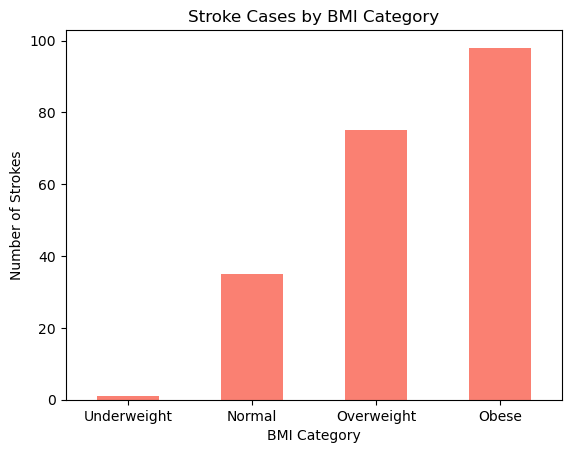

In [35]:
# Create BMI categories
df["bmi_category"] = pd.cut(df["bmi"], 
                             bins=[0, 18.5, 24.9, 29.9, 100],
                             labels=["Underweight", "Normal", "Overweight", "Obese"])

# Count strokes per BMI category
df.groupby("bmi_category",observed = True)["stroke"].sum().plot(kind="bar", color="salmon")
plt.title("Stroke Cases by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Number of Strokes")
plt.xticks(rotation=0)
plt.show()

When BMI is categorized into groups (underweight, normal, overweight, and obese), a clear trend emerges: the proportion of stroke cases increases progressively with higher BMI categories  
This confirms that BMI is a relevant feature and should be retained in the model  
For the bmi category, the outliers will be removed and the missing bmi values will be filled

In [37]:
df["bmi_category"].value_counts()

bmi_category
Obese          1920
Overweight     1409
Normal         1231
Underweight     349
Name: count, dtype: int64

In [39]:
# remove the bmi_category
df.drop(columns=['bmi_category'], inplace=True)

In [41]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


##### avg_glucose_level

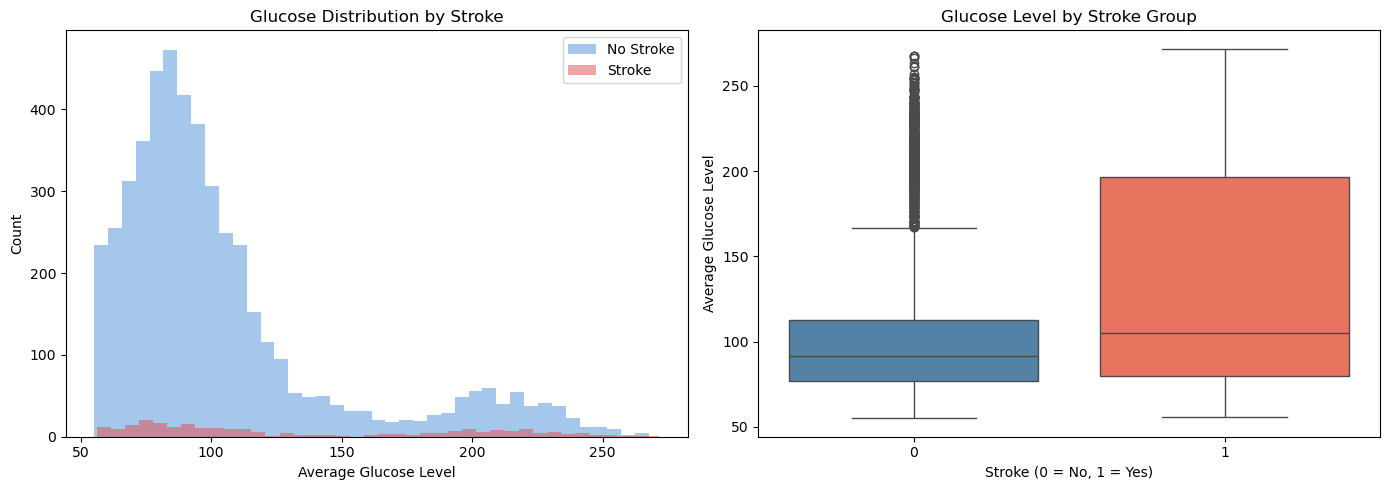

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overlayed histogram
df.loc[df.stroke == 0, "avg_glucose_level"].plot(
    kind="hist", bins=40, ax=axes[0], alpha=0.5, color="#4A90D9", label="No Stroke")
df.loc[df.stroke == 1, "avg_glucose_level"].plot(
    kind="hist", bins=40, ax=axes[0], alpha=0.5, color="#E24B4A", label="Stroke")
axes[0].set_title("Glucose Distribution by Stroke")
axes[0].set_xlabel("Average Glucose Level")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot 2: Boxplot
sns.boxplot(data=df, x="stroke", y="avg_glucose_level",hue="stroke", legend=False,
            palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title("Glucose Level by Stroke Group")
axes[1].set_xlabel("Stroke (0 = No, 1 = Yes)")
axes[1].set_ylabel("Average Glucose Level")

plt.tight_layout()
plt.show()

In [46]:
# What percentage of each group has glucose higher than 140 (diabetic threshold)
high_glucose_stroke    = (df.loc[df.stroke == 1, "avg_glucose_level"] > 140).mean() * 100
high_glucose_no_stroke = (df.loc[df.stroke == 0, "avg_glucose_level"] > 140).mean() * 100

print(f"High glucose in stroke group:    {high_glucose_stroke:.1f}%")
print(f"High glucose in no-stroke group: {high_glucose_no_stroke:.1f}%")

High glucose in stroke group:    37.3%
High glucose in no-stroke group: 15.0%


Stroke patients are 2,5 times more likely to have high glucose levels than non stroke patients   
Feature Avg_glucose_level shows a moderate separation between stroke and non stroke patients

#### 3.d Features Numeric columns (discrete), hypertension, heart_disease

##### Hypertension

In [50]:
df['hypertension'].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

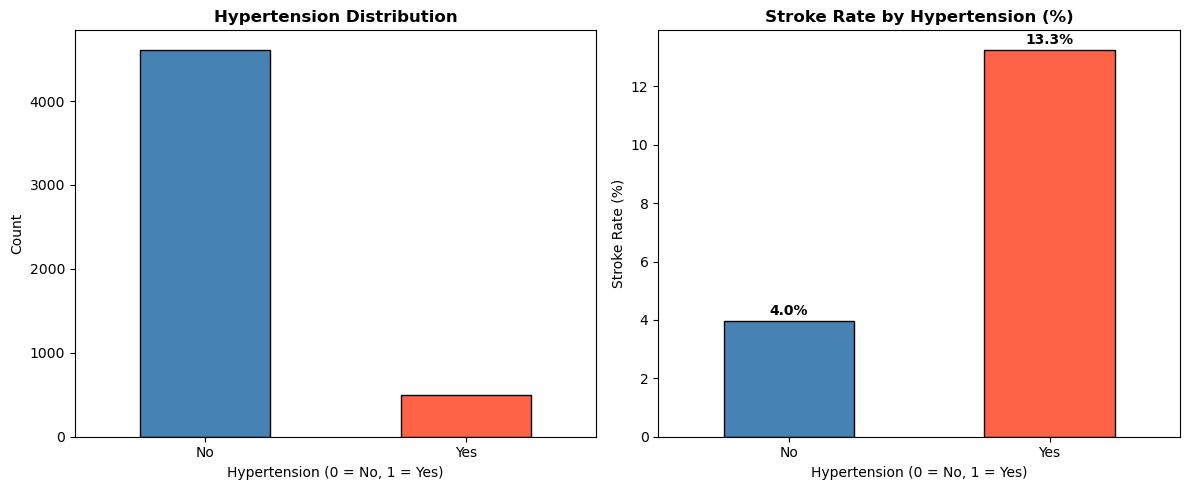

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count distribution
df['hypertension'].value_counts().plot(kind='bar', ax=axes[0], 
                                        color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Hypertension Distribution', fontweight='bold')
axes[0].set_xlabel('Hypertension (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Stroke rate by hypertension
stroke_rate = df.groupby('hypertension')['stroke'].mean() * 100
stroke_rate.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Stroke Rate by Hypertension (%)', fontweight='bold')
axes[1].set_xlabel('Hypertension (0 = No, 1 = Yes)')
axes[1].set_ylabel('Stroke Rate (%)')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
for i, v in enumerate(stroke_rate.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [54]:
df['hypertension'].corr(df['stroke'])
### Correlation stroke hypertension 

0.12790382346647935

Patients with hypertension have a significantly higher stroke rate, it can be an important predictor 

##### Heart disease

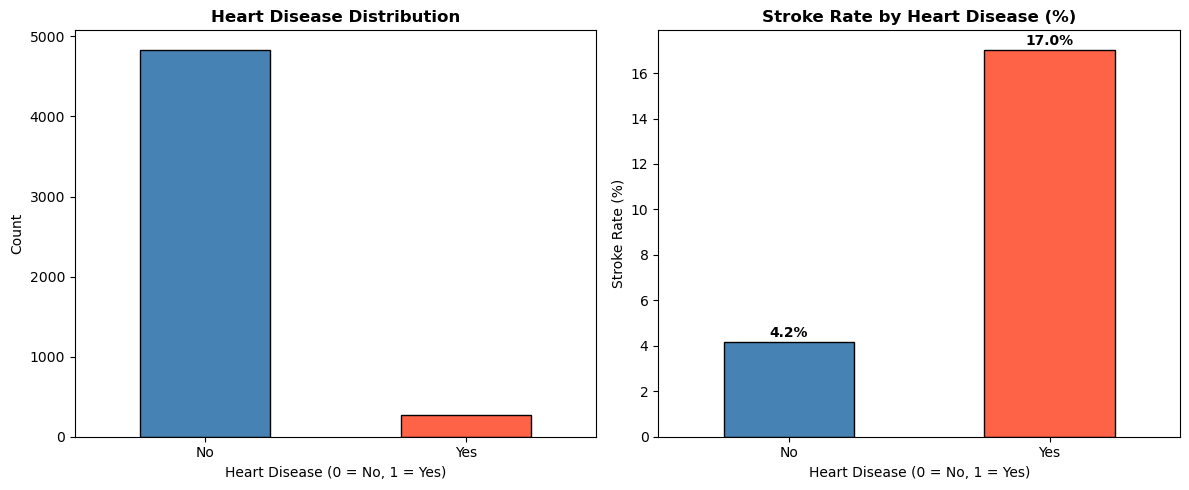

Heart disease rate: 5.4%
Correlation with stroke: 0.1349


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count distribution
df['heart_disease'].value_counts().plot(kind='bar', ax=axes[0], 
                                        color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Heart Disease Distribution', fontweight='bold')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Stroke rate by heart disease
stroke_rate = df.groupby('heart_disease')['stroke'].mean() * 100
stroke_rate.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Stroke Rate by Heart Disease (%)', fontweight='bold')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Stroke Rate (%)')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
for i, v in enumerate(stroke_rate.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Heart disease rate: {df['heart_disease'].mean()*100:.1f}%")
print(f"Correlation with stroke: {df['heart_disease'].corr(df['stroke']):.4f}")

Patients with heart disease show a significantly higher stroke rate, suggesting it could be a good predictor alongside age and hypertension  
I also see a weak positive correlation

#### 3.e Categorical features : gender, ever_married, work_type, residence_type, smoking_status

##### Gender 

In [162]:
df["gender"].value_counts()
## We have only one row "Other" in gender 

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [164]:
df.groupby("gender")["stroke"].value_counts()
## The gender Other didn't have a stroke, I will remove this line during the feature engineering and selection part
# The number of stroke are well balanced between male and female 

gender  stroke
Female  0         2853
        1          141
Male    0         2007
        1          108
Other   0            1
Name: count, dtype: int64

##### Ever_married 

In [168]:
df["ever_married"].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

In [170]:
df.groupby("ever_married")["stroke"].sum()
## More stroke in the married group than in the non married group 

ever_married
No      29
Yes    220
Name: stroke, dtype: int64

In [172]:
df.groupby(["ever_married", "stroke"])["age"].mean()
## The stroke status depends also on the age not only on the married status (married people are older) 

ever_married  stroke
No            0         21.286852
              1         65.355862
Yes           0         53.380147
              1         68.040909
Name: age, dtype: float64

In [174]:
## Categorical : ever_married 
print(df.groupby("ever_married")["age"].mean())
## ever married might be confounded by age, will see if I keep it or not later

ever_married
No     22.014229
Yes    54.342082
Name: age, dtype: float64


##### Work_type

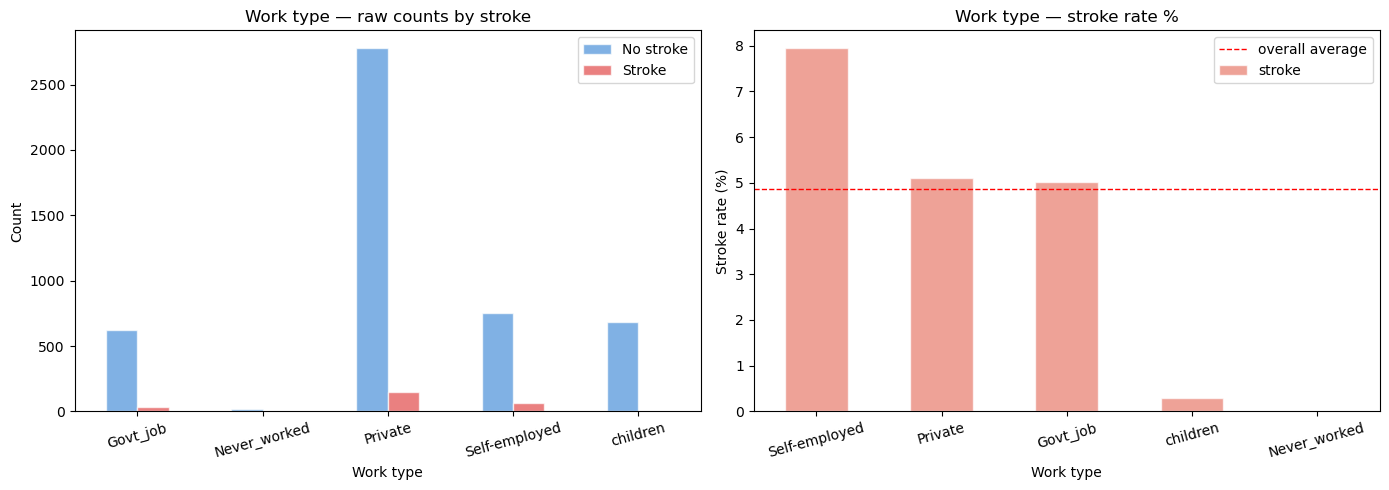

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts by work_type and stroke
df.groupby(["work_type", "stroke"]).size().unstack().plot(
    kind="bar", ax=axes[0],
    color=["#4A90D9", "#E24B4A"],
    alpha=0.7, edgecolor="white",
    rot=15)
axes[0].set_title("Work type — raw counts by stroke")
axes[0].set_xlabel("Work type")
axes[0].set_ylabel("Count")
axes[0].legend(["No stroke", "Stroke"])

# Right: stroke rate % by work_type
df.groupby("work_type")["stroke"].mean().mul(100).sort_values(ascending=False).plot(
    kind="bar", ax=axes[1],
    color="#E87B6B",
    alpha=0.7, edgecolor="white",
    rot=15)
axes[1].set_title("Work type — stroke rate %")
axes[1].set_xlabel("Work type")
axes[1].set_ylabel("Stroke rate (%)")
axes[1].axhline(y=df["stroke"].mean()*100, color="red",
                linestyle="--", linewidth=1, label="overall average")
axes[1].legend()

plt.tight_layout()
plt.show()

Stroke rate higher for self employed, private and gvt job, null in children and low in never worked   
Higher risk group are self_employees, private and gvt job (so basically people with a job)

In [184]:
df.groupby("work_type")["age"].mean().sort_values(ascending=False).round(1)

work_type
Self-employed    60.2
Govt_job         50.9
Private          45.5
Never_worked     16.2
children          6.8
Name: age, dtype: float64

Worker are older than non worker explaining the reduced nb of stroke in the non worker category 

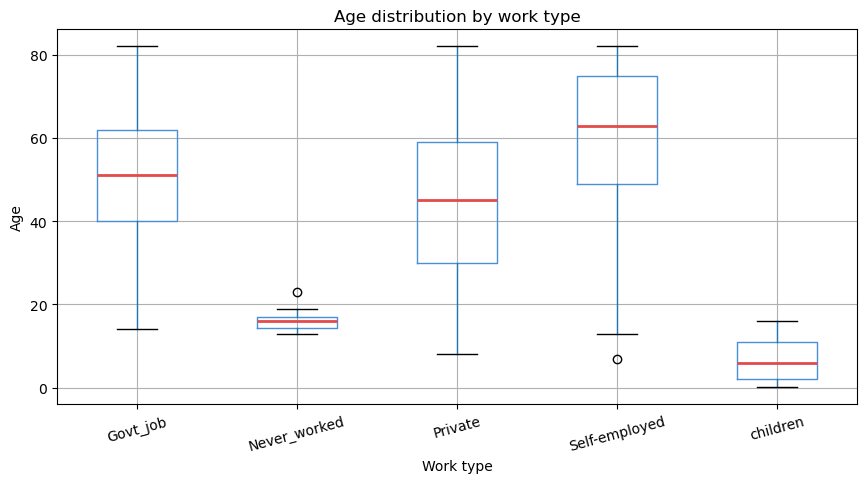

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

df.boxplot(column="age", by="work_type", ax=ax,
           boxprops=dict(color="#4A90D9"),
           medianprops=dict(color="#E24B4A", linewidth=2))

ax.set_title("Age distribution by work type")
ax.set_xlabel("Work type")
ax.set_ylabel("Age")
plt.suptitle("")
plt.xticks(rotation=15)
plt.show()

work_type significance is mostly due to age , I will keep it and let the model decide (tree-based models for exemple)

##### Residence_type

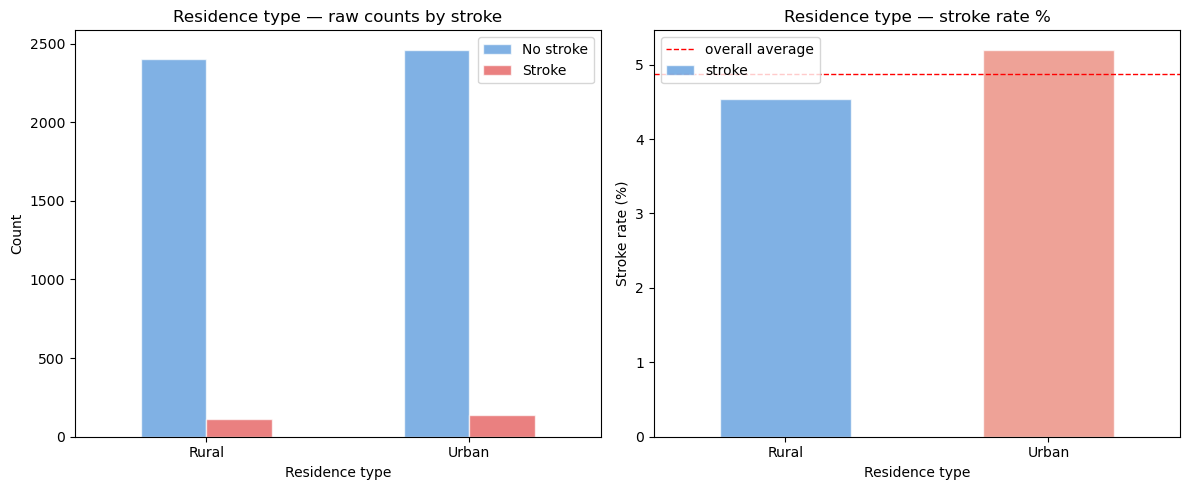

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: raw counts by Residence_type and stroke
df.groupby(["Residence_type", "stroke"]).size().unstack().plot(
    kind="bar", ax=axes[0],
    color=["#4A90D9", "#E24B4A"],
    alpha=0.7, edgecolor="white",
    rot=0)
axes[0].set_title("Residence type — raw counts by stroke")
axes[0].set_xlabel("Residence type")
axes[0].set_ylabel("Count")
axes[0].legend(["No stroke", "Stroke"])

# Right: stroke rate % by Residence_type
df.groupby("Residence_type")["stroke"].mean().mul(100).plot(
    kind="bar", ax=axes[1],
    color=["#4A90D9", "#E87B6B"],
    alpha=0.7, edgecolor="white",
    rot=0)
axes[1].set_title("Residence type — stroke rate %")
axes[1].set_xlabel("Residence type")
axes[1].set_ylabel("Stroke rate (%)")
axes[1].axhline(y=df["stroke"].mean()*100, color="red",
                linestyle="--", linewidth=1, label="overall average")
axes[1].legend()

plt.tight_layout()
plt.show()

Residence type shows virtually no difference in stroke rate between urban and rural patients.
It is unlikely to be a useful predictor and could be remove during feature selection.

## 4. Correlation Matrix 

In [47]:
# Correlation matrix (could add one with all features)
corr = df.corr(numeric_only=True)

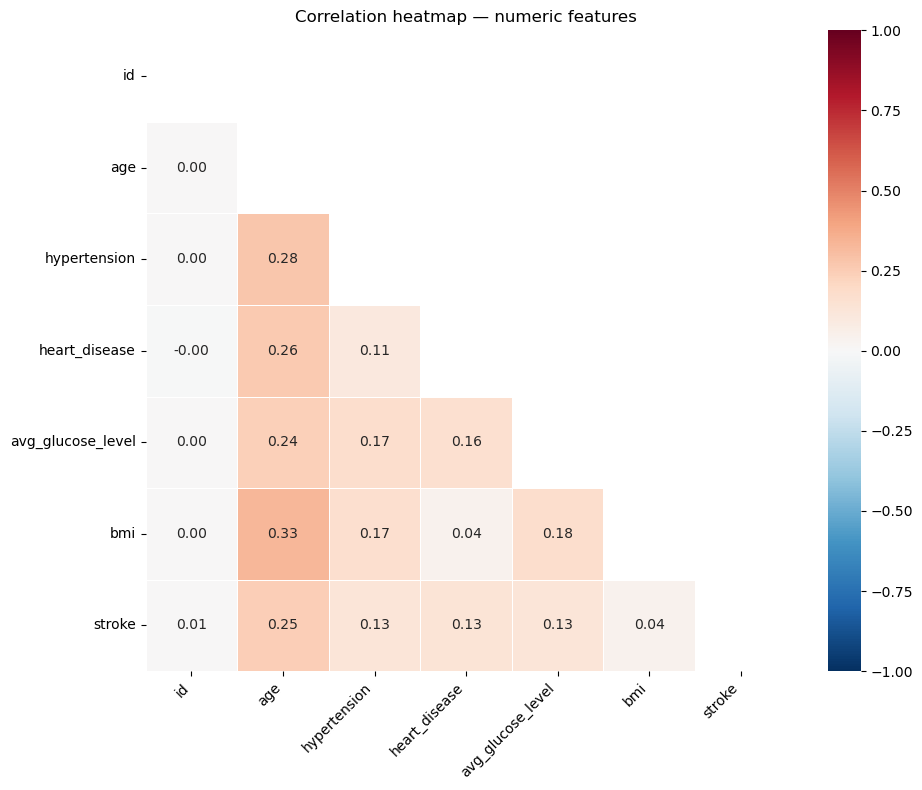

In [49]:
fig, ax = plt.subplots(figsize=(10, 8))

# mask the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title("Correlation heatmap — numeric features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Summary before feature engineering : 
Dataset is highly imbalanced (~5% stroke cases)  
Age, hypertension, heart disease and glucose appear to be strongly associated with stroke  
ID does not provide predictive values and can be removed  
Residence type shows weak relationship with stroke in EDA  
BMI has missing values that need to be handled in feature engineering, and outliers to be removed.  
Smoking status has an "Unknown" category that needs to be addressed  